In [1]:
print("بسم الله الرحمن الرحيم")

بسم الله الرحمن الرحيم


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [3]:
df = pd.read_csv('customer_purchases.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3665 entries, 0 to 3664
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   purchase_id     3665 non-null   int64
 1   customer_id     3665 non-null   str  
 2   purchase_date   3652 non-null   str  
 3   purchase_value  3602 non-null   str  
 4   channel         3622 non-null   str  
 5   region          3629 non-null   str  
 6   payment_method  3629 non-null   str  
 7   campaign_group  216 non-null    str  
dtypes: int64(1), str(7)
memory usage: 229.2 KB


In [5]:
df.isna().sum()

purchase_id          0
customer_id          0
purchase_date       13
purchase_value      63
channel             43
region              36
payment_method      36
campaign_group    3449
dtype: int64

In [6]:
df.sample(10)


,purchase_id,customer_id,purchase_date,purchase_value,channel,region,payment_method,campaign_group
51,1688,CUST0225,2025/09/17,NaN,Online,North,PayPal,NaN
1286,59,CUST0008,2022/04/17,89.35,ONLINE,East,Credit Card,NaN
434,2270,CUST0312,2022-06-10,110.3,online,west,Credit Card,NaN
3103,2907,CUST0389,2026/07/27,242.56,Online,West,Credit Card,NaN
979,2863,CUST0385,2024/04/26,80.07,In-Store,West,Credit Card,NaN
2161,3551,CUST0474,2023/01/02,118.43,Online,East,Credit Card,NaN
1871,3343,CUST0444,2024/04/12,187.23,online,East,Credit Card,NaN
2529,706,cust0107,2023-06-09,222.63,Online,south,Debit Card,NaN
3664,1946,CUST0266,02/06/2026,146.13,Online,East,Debit Card,A
2364,1941,CUST0266,07/31/2024,116.29,Online,East,Debit Card,NaN


## Cleaning DataFrame

In [7]:
## Fixing Data Column

df['purchase_date'] = pd.to_datetime(df['purchase_date'] , format='mixed', errors='coerce')
df['purchase_date'].isna().sum()
df['purchase_date']

0      2024-12-30
1      2026-06-24
2      2025-12-04
3      2023-07-28
4      2024-02-13
          ...    
3660   2022-03-20
3661   2021-12-08
3662   2024-09-02
3663   2025-02-10
3664   2026-02-06
Name: purchase_date, Length: 3665, dtype: datetime64[us]

In [8]:
df['purchase_date'].sample(10)

1184   2020-03-07
3243   2024-08-23
130    2021-08-21
1250   2023-01-16
1750   2023-03-14
2635   2025-01-03
477    2026-06-05
1385   2025-02-01
2826   2025-02-28
1002   2025-06-20
Name: purchase_date, dtype: datetime64[us]

In [9]:
df['purchase_value'] = df['purchase_value'].str.strip("$-").fillna('')
df['purchase_value'] =  pd.to_numeric(df['purchase_value'],errors='coerce')

In [10]:
df['purchase_value'] = df['purchase_value'].fillna(df['purchase_value'].median())

In [11]:
df['purchase_value'].sample(10)

1929     90.69
77      110.67
222     186.97
3107     73.97
1621    162.74
2277     90.71
1946    147.84
3277    142.89
1133    111.26
792     127.66
Name: purchase_value, dtype: float64

In [12]:
df_clean = df.dropna(subset='purchase_date')
df_clean

,purchase_id,customer_id,purchase_date,purchase_value,channel,region,payment_method,campaign_group
0,2551,CUST0351,2024-12-30,64.82,Online,East,Credit Card,NaN
1,3026,CUST0406,2026-06-24,101.77,Online,NORTH,Debit Card,NaN
2,2731,CUST0368,2025-12-04,101.90,Online,East,PayPal,NaN
3,1262,CUST0175,2023-07-28,94.04,In-Store,North,Credit Card,NaN
4,2132,CUST0291,2024-02-13,138.73,In-Store,North,Credit Card,NaN
...,...,...,...,...,...,...,...,...
3660,1294,CUST0179,2022-03-20,102.07,In-Store,West,Credit Card,NaN
3661,3410,CUST0454,2021-12-08,59.27,In-Store,North,Credit Card,NaN
3662,3164,CUST0424,2024-09-02,57.07,In-Store,West,Debit Card,NaN
3663,1105,CUST0157,2025-02-10,104.74,Online,South,Debit Card,NaN


In [13]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 3644 entries, 0 to 3664
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   purchase_id     3644 non-null   int64         
 1   customer_id     3644 non-null   str           
 2   purchase_date   3644 non-null   datetime64[us]
 3   purchase_value  3644 non-null   float64       
 4   channel         3602 non-null   str           
 5   region          3608 non-null   str           
 6   payment_method  3608 non-null   str           
 7   campaign_group  213 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 256.2 KB


In [14]:
df_clean['campaign_group'].sample(10)

678     NaN
2470    NaN
3096    NaN
1139    NaN
2376    NaN
2819    NaN
2680    NaN
3505    NaN
3437    NaN
223     NaN
Name: campaign_group, dtype: str

# Business Questions Answers

* Time Intellegence Analysis

In [15]:
df_clean['purchase_date']
df_clean['purchase_month'] = df_clean['purchase_date'].dt.month_name()
df_clean['purchase_year'] = df_clean['purchase_date'].dt.year
df_clean['purchase_day'] = df_clean['purchase_date'].dt.day_name()
df_clean['yearmonth'] = df_clean['purchase_date'].dt.strftime('%y-%m')


In [16]:
df_clean.set_index(['purchase_date'], inplace=True)

In [17]:
df_clean.sort_index(inplace=True)
df_clean = df_clean.map(lambda x: x.strip() if isinstance(x, str) else x)

### Monthly Trend

In [18]:
monthly_revenue = df_clean.groupby('yearmonth')['purchase_value'].sum()
monthly_revenue

yearmonth
20-02     158.94
20-03     584.08
20-04     380.96
20-05    4040.42
20-06     540.87
          ...   
26-08    1057.22
26-09     247.40
26-10    1076.99
26-11     371.61
26-12     552.54
Name: purchase_value, Length: 83, dtype: float64

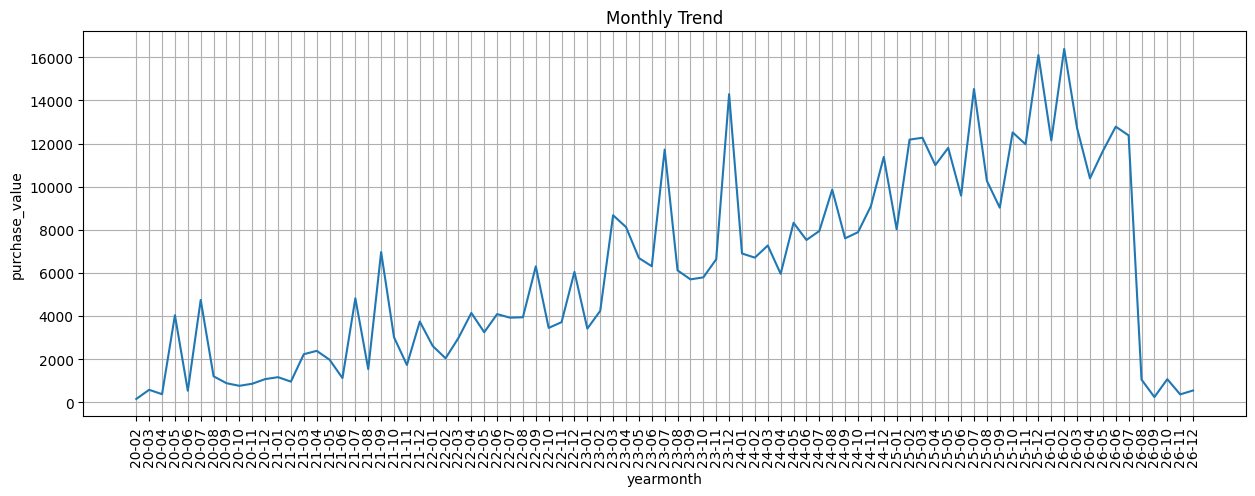

In [19]:
plt.figure(figsize=(15,5))
sns.lineplot(monthly_revenue)
plt.xticks(rotation=90)
plt.grid()
plt.title("Monthly Trend")
plt.show()

### Weekdays Averages

In [20]:
week_days = ['Saturday', 'Sunday','Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekday_average = df_clean.groupby('purchase_day')['purchase_value'].mean().reindex(index=week_days)
weekday_average = weekday_average.to_frame().reset_index()
weekday_average

,purchase_day,purchase_value
0,Saturday,154.403065
1,Sunday,138.367947
2,Monday,126.065629
3,Tuesday,164.068187
4,Wednesday,130.237727
5,Thursday,139.507304
6,Friday,127.873027


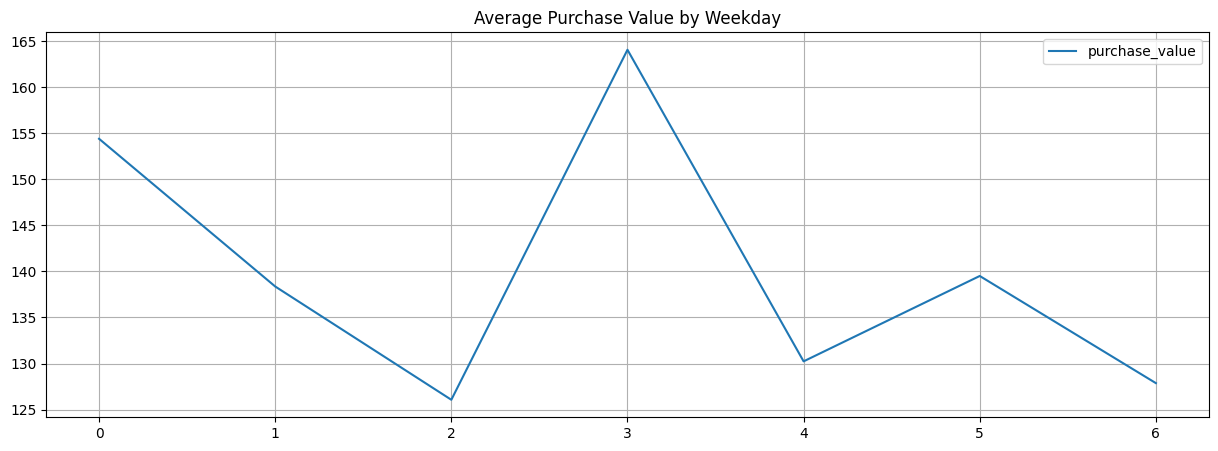

In [21]:
plt.figure(figsize=(15,5))
sns.lineplot(weekday_average)
plt.grid()
plt.title("Average Purchase Value by Weekday")
plt.show()

### Customer recency

In [22]:
df_clean.head(10)

,purchase_id,customer_id,purchase_value,channel,region,payment_method,campaign_group,purchase_month,purchase_year,purchase_day,yearmonth
purchase_date,,,,,,,,,,,
2020-02-29,2724,CUST0368,158.94,Online,East,PayPal,NaN,February,2020,Saturday,20-02
2020-03-06,2855,CUST0384,52.75,In-Store,West,Credit Card,NaN,March,2020,Friday,20-03
2020-03-07,3174,CUST0425,42.76,In-Store,South,Debit Card,NaN,March,2020,Saturday,20-03
2020-03-11,1916,CUST0259,82.09,in-store,South,Debit Card,NaN,March,2020,Wednesday,20-03
2020-03-19,52,CUST0007,131.08,Online,north,Debit Card,NaN,March,2020,Thursday,20-03
2020-03-23,700,CUST0106,90.97,In-Store,South,Credit Card,NaN,March,2020,Monday,20-03
2020-03-23,700,CUST0106,90.97,In-Store,south,Credit Card,NaN,March,2020,Monday,20-03
2020-03-27,1357,CUST0184,93.46,Instore,South,Credit Card,NaN,March,2020,Friday,20-03
2020-04-03,49,CUST0007,73.33,Online,North,Credit Card,NaN,April,2020,Friday,20-04


In [23]:
df_clean = df_clean.reset_index()
customer_recency = df_clean.groupby('customer_id')['purchase_date'].max()
customer_recency = customer_recency.to_frame(name='last_date')
customer_recency['last_date'] = df_clean.groupby('customer_id')['purchase_date'].max()
customer_recency['today_date'] = pd.Timestamp('08-10-2026')
customer_recency['days_since_last_purchace'] = (customer_recency['today_date'] - customer_recency['last_date'] ).dt.days
customer_recency.sort_values('days_since_last_purchace', ascending= True)


,last_date,today_date,days_since_last_purchace
customer_id,,,
CUST0047,2026-12-07,2026-08-10,-119
CUST0158,2026-12-03,2026-08-10,-115
CUST0046,2026-12-02,2026-08-10,-114
CUST0157,2026-12-02,2026-08-10,-114
CUST0461,2026-11-06,2026-08-10,-88
...,...,...,...
cust0179,2022-12-24,2026-08-10,1325
cust0424,2022-12-02,2026-08-10,1347
cust0438,2022-07-14,2026-08-10,1488


### Churn-Risk List
* customers with no purchase in the last 180 days

In [24]:
churn_risk = customer_recency[customer_recency['days_since_last_purchace'] > 180].sort_values('days_since_last_purchace', ascending= True)
churn_risk

,last_date,today_date,days_since_last_purchace
customer_id,,,
CUST0078,2026-02-10,2026-08-10,181
CUST0074,2026-02-09,2026-08-10,182
CUST0126,2026-02-09,2026-08-10,182
CUST0294,2026-02-08,2026-08-10,183
CUST0266,2026-02-06,2026-08-10,185
...,...,...,...
cust0179,2022-12-24,2026-08-10,1325
cust0424,2022-12-02,2026-08-10,1347
cust0438,2022-07-14,2026-08-10,1488


### Cohort Analysis
* Group Cuatomers According to their first purchase with the company

In [25]:
cohort = df_clean.groupby('customer_id')['purchase_date'].min()
cohort = cohort.to_frame('first_purchase')
cohort['cohort'] = cohort['first_purchase'].dt.strftime('%y-%m')
cohort


,first_purchase,cohort
customer_id,,
CUST0001,2022-07-14,22-07
CUST0002,2024-07-15,24-07
CUST0003,2025-10-30,25-10
CUST0004,2021-09-10,21-09
CUST0005,2024-04-06,24-04
...,...,...
cust0352,2023-02-08,23-02
cust0367,2026-05-13,26-05
cust0424,2022-12-02,22-12


In [26]:
df_merge = pd.merge(df_clean, cohort, on='customer_id',how='inner')
df_merge = df_merge.drop(columns=['first_purchase'])
df_clean = df_merge
df_clean.reset_index(drop=True, inplace=True)

In [27]:
df_clean.sample(10)

,purchase_date,purchase_id,customer_id,purchase_value,channel,region,payment_method,campaign_group,purchase_month,purchase_year,purchase_day,yearmonth,cohort
2363,2025-04-16,3533,CUST0472,2660.67,In-Store,east,PayPal,NaN,April,2025,Wednesday,25-04,21-12
970,2023-06-10,719,CUST0108,121.40,Online,West,Credit Card,NaN,June,2023,Saturday,23-06,23-02
2385,2025-04-30,1084,CUST0152,143.80,Online,South,PayPal,NaN,April,2025,Wednesday,25-04,24-04
2329,2025-03-26,2487,CUST0341,49.76,IN-STORE,NORTH,Debit Card,NaN,March,2025,Wednesday,25-03,22-04
1889,2024-09-29,1611,cust0217,113.16,Online,West,Credit Card,NaN,September,2024,Sunday,24-09,24-09
1383,2024-02-03,2725,CUST0368,64.57,Online,East,Credit Card,NaN,February,2024,Saturday,24-02,20-02
223,2021-08-23,1496,CUST0200,61.76,Online,East,Credit Card,NaN,August,2021,Monday,21-08,21-08
342,2022-01-01,1735,CUST0228,159.19,online,west,PayPal,NaN,January,2022,Saturday,22-01,21-06
2954,2025-12-04,1108,CUST0157,4410.29,In-Store,SOUTH,PayPal,NaN,December,2025,Thursday,25-12,23-11
3304,2026-04-14,1487,CUST0200,137.77,Online,East,Cash,NaN,April,2026,Tuesday,26-04,21-08


## Defining Confedince Interval Mean for Purchase values


### For Full Data Set

In [28]:
# Variables
Alpha = .95
Xbar = df_clean['purchase_value'].mean()
n = df_clean['purchase_value'].count()
s = df_clean['purchase_value'].std()
SEM = s/np.sqrt(n)

In [29]:
from scipy import stats
interval = stats.norm.interval(confidence=.95,loc= Xbar, scale= SEM)
print(f"Condidence Interval:{interval}")

Condidence Interval:(np.float64(131.56391100371135), np.float64(147.63229097213937))


In [30]:
# The average Purchase value is between 131 and 147 with confidence of 95%

### for 2025 only with confidence 95%

In [31]:
df_25 = df_clean[df_clean['purchase_year'] == 2025]
df_25.sample(5)

,purchase_date,purchase_id,customer_id,purchase_value,channel,region,payment_method,campaign_group,purchase_month,purchase_year,purchase_day,yearmonth,cohort
2440,2025-05-23,3224,CUST0431,169.20,In-Store,North,Credit Card,NaN,May,2025,Friday,25-05,22-09
2217,2025-02-13,137,CUST0021,60.98,Online,North,Credit Card,NaN,February,2025,Thursday,25-02,23-06
2522,2025-06-27,2420,CUST0333,83.93,In-Store,East,Credit Card,NaN,June,2025,Friday,25-06,21-04
2315,2025-03-22,92,CUST0013,128.80,In-Store,West,Debit Card,NaN,March,2025,Saturday,25-03,21-09
2265,2025-02-28,708,CUST0107,169.22,Online,South,Credit Card,NaN,February,2025,Friday,25-02,23-05


In [32]:
# Variables:-
Xbar = df_25['purchase_value'].mean()
n = df_25['purchase_value'].count()
s = df_25['purchase_value'].std()
SEM = s/np.sqrt(n)


In [33]:
interval = stats.norm.interval(confidence=.95,loc= Xbar, scale= SEM)
print(f"confidence interval is between: {interval}")

confidence interval is between: (np.float64(133.92510679209786), np.float64(167.15763915384812))


In [34]:
#Average purchase for 2025 is between 90.9 and 210.1 with confedence 95%

### for 2025 only with confidence 95%

In [35]:
df_20 = df_clean[df_clean['purchase_year'] == 2020]
df_20

,purchase_date,purchase_id,customer_id,purchase_value,channel,region,payment_method,campaign_group,purchase_month,purchase_year,purchase_day,yearmonth,cohort
0,2020-02-29,2724,CUST0368,158.94,Online,East,PayPal,NaN,February,2020,Saturday,20-02,20-02
1,2020-03-06,2855,CUST0384,52.75,In-Store,West,Credit Card,NaN,March,2020,Friday,20-03,20-03
2,2020-03-07,3174,CUST0425,42.76,In-Store,South,Debit Card,NaN,March,2020,Saturday,20-03,20-03
3,2020-03-11,1916,CUST0259,82.09,in-store,South,Debit Card,NaN,March,2020,Wednesday,20-03,20-03
4,2020-03-19,52,CUST0007,131.08,Online,north,Debit Card,NaN,March,2020,Thursday,20-03,20-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,2020-12-23,3451,CUST0461,46.35,Online,South,PayPal,NaN,December,2020,Wednesday,20-12,20-08
84,2020-12-24,129,CUST0019,72.71,In-Store,South,Debit Card,NaN,December,2020,Thursday,20-12,20-12
85,2020-12-25,820,CUST0117,69.62,Online,South,Credit Card,NaN,December,2020,Friday,20-12,20-11
86,2020-12-28,2154,CUST0294,140.29,Online,East,PayPal,NaN,December,2020,Monday,20-12,20-12


In [36]:
## Variables
n = df_20['purchase_value'].count()
s = df_20['purchase_value'].std()
Xbar = df_20['purchase_value'].mean()
SEM = s/np.sqrt(n)

In [37]:
interval = stats.norm.interval(confidence= .95, loc= Xbar, scale= SEM)
print(F"CONFEDINCE INTERVAL FOR 2020 IS BETWEEN: {interval}")

CONFEDINCE INTERVAL FOR 2020 IS BETWEEN: (np.float64(61.82277380368619), np.float64(285.1388171054047))


## Hypothesis Testing: 
### is 2025 and 2020 average purchases significantly different from each others?

#### Null Hypothesis:
    Mean 2020 = Mean 2025 for purchase values.
#### Alternative hypothesis:
    Mean 2020 ≠ Mean 2025 for purchase values

### A/B Testing to test the Hypothesis
    A tow-Sample T-test will be made to check the hypothesis

In [38]:
Significance_level = 0.05
a = df_20['purchase_value']
b = df_25['purchase_value']
test_result = stats.ttest_ind(a=a,b=b)
test_result


TtestResult(statistic=np.float64(0.7039064739462546), pvalue=np.float64(0.4816531075094801), df=np.float64(1011.0))

as pvalue > significance level
we fail to reject the null Hypothesis so, there is no statistical evidence that Mean 2020  ≠ Mean 2025

### Testing the hypothesis that mean value is 120

#### Null Hypothesis : 
    Average purchase value is 120$ for the full dataset
#### Alternative Hypothesis :
    average purchase ≠ 120
we will be having a two-tailed Test

In [39]:
test_result = stats.ttest_1samp(df_clean['purchase_value'],120, alternative= 'two-sided')
test_result

TtestResult(statistic=np.float64(4.781013664997425), pvalue=np.float64(1.813107578529073e-06), df=np.int64(3643))

p-value < significance level '0.05',
in this case we reject the Null Hypothesis
there is a strong statistical evidence that the mean is not 120$

In [40]:
sample_data = df_clean[df_clean['region'] == 'north']
sample_data

,purchase_date,purchase_id,customer_id,purchase_value,channel,region,payment_method,campaign_group,purchase_month,purchase_year,purchase_day,yearmonth,cohort
4,2020-03-19,52,CUST0007,131.08,Online,north,Debit Card,NaN,March,2020,Thursday,20-03,20-03
248,2021-09-22,496,CUST0079,1488.81,In-Store,north,Credit Card,NaN,September,2021,Wednesday,21-09,21-08
252,2021-09-28,1375,CUST0186,86.65,Online,north,Debit Card,NaN,September,2021,Tuesday,21-09,21-09
268,2021-10-14,1794,CUST0237,69.15,In-Store,north,PayPal,NaN,October,2021,Thursday,21-10,20-10
303,2021-11-30,885,CUST0130,131.48,In-Store,north,PayPal,NaN,November,2021,Tuesday,21-11,20-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3532,2026-07-03,517,CUST0083,164.67,In-Store,north,Cash,NaN,July,2026,Friday,26-07,25-02
3584,2026-07-23,386,CUST0061,164.90,IN-STORE,north,Credit Card,NaN,July,2026,Thursday,26-07,24-12
3594,2026-07-24,735,CUST0110,92.02,NaN,north,Debit Card,NaN,July,2026,Friday,26-07,23-02
3599,2026-07-26,32,CUST0006,194.90,Online,north,Credit Card,NaN,July,2026,Sunday,26-07,23-06


#### Null Hypothesis:
    Mean purchase value for North Region = 115
#### Alternative hypothesis:
    Mean purchase value for North Region ≠ 115

In [41]:
test_result = stats.ttest_1samp(sample_data['purchase_value'], 115, alternative='two-sided')
test_result

TtestResult(statistic=np.float64(1.598575964065589), pvalue=np.float64(0.11423455359953925), df=np.int64(73))

    pvalue is > signifecance level '0.05',
    in this case we fail to reject the H0 ,
    there is no statistical evidence that average purchase value for North Region ≠ 115

#### Is there a significant difference in average purchase value between Online and In-Store?

In [42]:
in_store = df_clean[df_clean['channel'] == 'In-Store']
online = df_clean[df_clean['channel'] == 'Online']


#### Null Hypothesis:
    Mean purchase value for Online = Mean purchase value for In-Store
#### Alternative hypothesis:
    Mean purchase value for Online ≠ Mean purchase value for In-Store

In [43]:
test_result = stats.ttest_ind(in_store['purchase_value'], online['purchase_value'])
test_result

TtestResult(statistic=np.float64(-2.334622974012615), pvalue=np.float64(0.01962950736895474), df=np.float64(2967.0))

    as long as pvalue is < significance level then we reject the NUll Hypothesis.
    there is a statistical evidence that both categories are not the same average purchase value

## A/B Testing for email campaign 

#### Null Hypothesis:
    Mean purchase value for Group A = Mean purchase value for Group B
#### Alternative hypothesis:
   Mean purchase value for Group A ≠ Mean purchase value for Group B

In [44]:
group_a = df_clean[df_clean['campaign_group'] == 'A']
group_b = df_clean[df_clean['campaign_group'] == 'B']

In [45]:
test_result = stats.ttest_ind(group_a['purchase_value'],group_b['purchase_value'])
test_result

TtestResult(statistic=np.float64(-2.8747680543064957), pvalue=np.float64(0.004457340707233366), df=np.float64(211.0))

    as long as pvalue is < significance level '0.05'
    in this case we reject the null hypothesis
    there IS statistical evidence that Mean A ≠ Mean B

### 95% CI for the difference in means between A and B. 

In [46]:
# Variables
n_a = group_a['purchase_value'].count()
n_b = group_b['purchase_value'].count()
xbar_a  = group_a['purchase_value'].mean()
Xbar_b = group_b['purchase_value'].mean()
xbar = Xbar_b - xbar_a
s_a = group_a['purchase_value'].std()
s_b = group_b['purchase_value'].std()
# SEM = s/ np.sqrt(n)
SEM = (s_a/np.sqrt(n_a)) + (s_b/np.sqrt(n_b))


In [47]:
interval = stats.norm.interval(confidence=.95, loc= xbar, scale= SEM)
interval

(np.float64(0.46679118948740417), np.float64(27.533617660070114))

    The diffrence in mean between A and B is between 0.467 and 27.534 with confedince 95%

### Do Credit Card purchases have a higher average value than Cash purchases? 


In [48]:
df_clean.sample(10)

,purchase_date,purchase_id,customer_id,purchase_value,channel,region,payment_method,campaign_group,purchase_month,purchase_year,purchase_day,yearmonth,cohort
2904,2025-11-20,2136,CUST0292,187.63,Online,North,Credit Card,NaN,November,2025,Thursday,25-11,24-08
3633,2026-10-05,2582,CUST0354,153.31,Online,East,Debit Card,NaN,October,2026,Monday,26-10,22-06
3489,2026-06-17,2586,CUST0354,171.89,In-Store,East,Debit Card,NaN,June,2026,Wednesday,26-06,22-06
87,2020-12-28,601,CUST0095,101.65,Online,South,Cash,NaN,December,2020,Monday,20-12,20-12
828,2023-03-22,1457,CUST0196,111.86,In-Store,South,Debit Card,NaN,March,2023,Wednesday,23-03,22-06
2600,2025-07-26,2901,CUST0388,69.42,In-Store,South,Credit Card,NaN,July,2025,Saturday,25-07,22-11
1501,2024-04-02,1237,CUST0173,41.00,IN-STORE,North,Cash,NaN,April,2024,Tuesday,24-04,22-03
2770,2025-10-07,393,CUST0063,155.42,Online,south,PayPal,NaN,October,2025,Tuesday,25-10,25-03
1966,2024-11-07,757,CUST0111,164.08,Online,North,Debit Card,NaN,November,2024,Thursday,24-11,20-07
2824,2025-10-24,2511,CUST0346,113.60,Online,North,Debit Card,NaN,October,2025,Friday,25-10,23-06


In [49]:
df_credit = df_clean[df_clean['payment_method'] == 'Credit Card']
df_cash = df_clean[df_clean['payment_method'] == 'Cash']

#### Null Hypothesis:
    Mean purchase value for credit card purchase <= Mean purchase value for Cash Purchase
#### Alternative hypothesis:
    Mean purchase value for credit card purchase > Mean purchase value for Cash Purchase


In [50]:
test_results = stats.ttest_ind(df_credit['purchase_value'],df_cash['purchase_value'])
test_results

TtestResult(statistic=np.float64(0.6244153893402314), pvalue=np.float64(0.5324327417501633), df=np.float64(1828.0))

    we fail to reject the H0 as there is no statistical evidence that mean ourchase value for Credit cards > Cash purchase 

### Do weekend purchases differ significantly from weekday purchases in value? 

In [118]:
df_weekend = df_clean[df_clean['purchase_day'].str.lower().isin(['saturday','sunday'])]
df_weekday = df_clean[~df_clean['purchase_day'].str.lower().isin(['saturday','sunday'])]

#### Null Hypothesis:
    Mean purchase value for weekdays = Mean purchase value for Weekend
#### Alternative hypothesis:
    Mean purchase value for weekdays != Mean purchase value for Weekend


In [119]:
test_result = stats.ttest_ind(df_weekday['purchase_value'],df_weekend['purchase_value'])
test_result

TtestResult(statistic=np.float64(-1.022672571553793), pvalue=np.float64(0.30653060707556495), df=np.float64(3642.0))

    as pvalue > significance level, we fail to reject the H0
    so we have a statistical evidence that "Mean purchase value for weekdays = Mean purchase value for Weekend"
